In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
from torch.profiler import profile, ProfilerActivity, schedule, record_function

In [3]:
device = "cuda:0"

# Загрузка квантизованной модели

In [4]:
# 1. Создаем экземпляр модели (той же, что была на обучении, Unet c QAConv2d)
# model = Unet(encoder_name='efficientnet-b4', classes=27)

# 2. Загружаем веса, созраненные после обучения в fp32 torch.save(\model.state_dict(), 'unet_lsq_trained.pth')
# model.load_state_dict(torch.load('unet_lsq_trained.pth', map_location='cpu'))

In [5]:
# Ниже код загрузки в отсутвии обученной модели
# Заменить в дальнейшем на обученную модель

In [4]:
# функция для контроля подмены слоёв модели
from collections import Counter


def count_layers(model):
    counts = Counter()
    for m in model.modules():
        counts[type(m).__name__] += 1
    
    print(f"Слоев для обучения (QAConv2d): {counts['QAConv2d']}")
    print(f"Слоев для инференса (QAConv2dInference): {counts['QAConv2dInference']}")
    print(f"Слоев для инференса (LSQConv2dTriton): {counts['LSQConv2dTriton']}")
    print(f"Обычных слоев (Conv2dStaticSamePadding): {counts['Conv2dStaticSamePadding']}")
    print(f"Обычных слоев (Conv2d): {counts['Conv2d']}")
    
    return counts

In [5]:
import torch
from segmentation_models_pytorch import Unet as SMPUnet


class Unet(SMPUnet):
    """
    Кастомная реализация UNet с загрузкой весов энкодера из файла.
    """

    def __init__(
        self,
        encoder_name: str = 'efficientnet-b4',
        encoder_depth: int = 5,
        encoder_weights: str | None = None,
        decoder_use_batchnorm: bool = True,
        decoder_channels: list[int] = [256, 128, 64, 32, 16],
        decoder_attention_type: str | None = 'scse',
        in_channels: int = 3,
        classes: int = 27,
        activation: str | None = None,
        aux_params: dict | None = None,
        **kwargs,
    ):
        super().__init__(
            encoder_name=encoder_name,
            encoder_depth=encoder_depth,
            encoder_weights=None,
            decoder_use_batchnorm=decoder_use_batchnorm,
            decoder_channels=decoder_channels,
            decoder_attention_type=decoder_attention_type,
            in_channels=in_channels,
            classes=classes,
            activation=activation,
            aux_params=aux_params,
            **kwargs,
        )

        if encoder_weights is not None:
            state_dict = torch.load(encoder_weights, map_location='cpu')
            try:
                self.encoder.load_state_dict(state_dict, strict=False)
                print('Веса загружены вручную')
            except Exception as e:
                raise RuntimeError(
                    f'Не удалось загрузить веса из файла {weights_path}: {e}'
                )

model = Unet(encoder_weights='/pub/home/tjumentseva/projects/fields_segmentation/weights/pretrained/efficientnet-b4-6ed6700e.pth')

/pub/home/tjumentseva/env/fields_segmentation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Веса загружены вручную


In [6]:
count_layers(model)

Слоев для обучения (QAConv2d): 0
Слоев для инференса (QAConv2dInference): 0
Слоев для инференса (LSQConv2dTriton): 0
Обычных слоев (Conv2dStaticSamePadding): 160
Обычных слоев (Conv2d): 41


Counter({'Conv2dStaticSamePadding': 160,
         'Identity': 134,
         'BatchNorm2d': 106,
         'Conv2d': 41,
         'ZeroPad2d': 33,
         'SiLU': 33,
         'MBConvBlock': 32,
         'ReLU': 20,
         'Sequential': 20,
         'Sigmoid': 20,
         'AdaptiveAvgPool2d': 11,
         'Conv2dReLU': 10,
         'Attention': 10,
         'SCSEModule': 10,
         'UnetDecoderBlock': 5,
         'ModuleList': 2,
         'Unet': 1,
         'EfficientNetEncoder': 1,
         'Dropout': 1,
         'UnetDecoder': 1,
         'SegmentationHead': 1,
         'Activation': 1})

In [7]:
class LSQFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, s_grad_scale, Qn, Qp):
        ctx.save_for_backward(x, scale)
        ctx.s_grad_scale = s_grad_scale
        ctx.Qn = Qn
        ctx.Qp = Qp
        
        x_scaled = x / scale
        x_clamped = torch.clamp(torch.round(x_scaled), Qn, Qp)
        x_quant = x_clamped * scale
        return x_quant

    @staticmethod
    def backward(ctx, grad_output):
        x, scale = ctx.saved_tensors
        s_grad_scale = ctx.s_grad_scale
        Qn, Qp = ctx.Qn, ctx.Qp
        
        x_scale = x / scale
        indicate_small = (x_scale <= Qn).float()
        indicate_big = (x_scale >= Qp).float()
        indicate_middle = 1.0 - indicate_small - indicate_big

        grad_scale = (indicate_small * Qn + indicate_big * Qp + 
                  indicate_middle * (-x_scale + torch.round(x_scale))) * grad_output
        grad_scale = grad_scale.sum().unsqueeze(0) * s_grad_scale
        
        grad_x = indicate_middle * grad_output
        
        return grad_x, grad_scale, None, None, None

In [8]:
class QAConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, n_bits=8, static_padding=None, **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, **kwargs)
        self.n_bits = n_bits
        self.Qn = -2**(n_bits - 1)
        self.Qp = 2**(n_bits - 1) - 1
        
        self.static_padding = static_padding 
        self.weight_scale = nn.Parameter(torch.ones(1))
        self.x_scale = nn.Parameter(torch.ones(1))        
        self.initialized = False
        
        self.register_buffer('init_state', torch.tensor(False, dtype=torch.bool))
        with torch.no_grad():
            self.weight_scale.data.copy_(2 * self.weight.abs().mean() / (self.Qp**0.5))

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        if self.training and not self.init_state:
            with torch.no_grad():
                self.x_scale.data.copy_(2 * max(x.abs().mean(), 1e-4) / (self.Qp**0.5))
                self.init_state.fill_(True)
        if self.training:
            weight_s_grad_scale = 1.0 / ((self.weight.numel() * self.Qp)**0.5)
            x_s_grad_scale = 1.0 / ((x.numel() * self.Qp)**0.5)
        else:
            weight_s_grad_scale =  x_s_grad_scale = 1.0

        quantized_weight = LSQFunction.apply(self.weight, self.weight_scale, weight_s_grad_scale, self.Qn, self.Qp)
        quantized_x = LSQFunction.apply(x, self.x_scale, x_s_grad_scale, self.Qn, self.Qp)

        return F.conv2d(quantized_x, quantized_weight, self.bias, self.stride, 
                        self.padding, self.dilation, self.groups)

In [9]:
def replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8):
    """
    Заменяет свёртки на QAConv2d в указанных частях модели
    
    Args:
        model: модель
        parts_to_replace: ['encoder', 'decoder', 'segmentation_head']
        bit_width: количество бит для квантования
    """
    def  replace_conv_with_lsq(module, n_bits):
        if isinstance(module, QAConv2d):
            return

        for name, child in module.named_children():
            # вручную пропускаем свёртки, которые не хотим менять
            if name in ('_conv_stem', '_conv_head'):
                print(f'Пропускаем {name}')
                continue
            if isinstance(child, nn.Conv2d):
                static_padding = None
                if hasattr(child, 'static_padding') and child.static_padding is not None:
                    if not isinstance(child.static_padding, nn.Identity):
                        static_padding = child.static_padding

                bias = child.bias is not None

                lsq_conv = QAConv2d(
                    child.in_channels,
                    child.out_channels,
                    child.kernel_size,
                    n_bits=n_bits,
                    static_padding=static_padding,
                    stride=child.stride,
                    padding=child.padding,
                    dilation=child.dilation,
                    groups=child.groups,
                    bias=bias,
                )

                lsq_conv.weight.data.copy_(child.weight.data)
                if bias:
                    lsq_conv.bias.data.copy_(child.bias.data)

                setattr(module, name, lsq_conv)
            else:
                replace_conv_with_lsq(child, n_bits)
    

    if isinstance(parts_to_replace, str):
        parts_to_replace = [parts_to_replace]

    for part_name in parts_to_replace:
        if hasattr(model, part_name):
            part_module = getattr(model, part_name)
            replace_conv_with_lsq(part_module, bit_width)

In [10]:
replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8)
count_layers(model)

Пропускаем _conv_stem
Пропускаем _conv_head
Слоев для обучения (QAConv2d): 198
Слоев для инференса (QAConv2dInference): 0
Слоев для инференса (LSQConv2dTriton): 0
Обычных слоев (Conv2dStaticSamePadding): 2
Обычных слоев (Conv2d): 1


Counter({'QAConv2d': 198,
         'BatchNorm2d': 106,
         'ZeroPad2d': 33,
         'SiLU': 33,
         'MBConvBlock': 32,
         'ReLU': 20,
         'Sequential': 20,
         'Sigmoid': 20,
         'AdaptiveAvgPool2d': 11,
         'Conv2dReLU': 10,
         'Attention': 10,
         'SCSEModule': 10,
         'Identity': 8,
         'UnetDecoderBlock': 5,
         'Conv2dStaticSamePadding': 2,
         'ModuleList': 2,
         'Unet': 1,
         'EfficientNetEncoder': 1,
         'Dropout': 1,
         'UnetDecoder': 1,
         'SegmentationHead': 1,
         'Conv2d': 1,
         'Activation': 1})

# Квантизация с использованием F.conv2d на инференсе

In [14]:
# Имплементация инференса квантизованной модели
# Активация и веса округляются до битности, при котором происходило обучение, и подаются непосредственно в F.conv2d

In [11]:
model.eval()
model.to(device)

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): QAConv2d(
          48, 48, kernel_size=(3, 3), stride=(1, 1), groups=48, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): QAConv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
        (_se_expand): QAConv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
        (_project_conv): QAConv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (_bn2): BatchNorm2d(24, eps=0.001, momentum=0.0100

In [12]:
class QAConv2dInference(nn.Conv2d):
    def __init__(self, original_layer):
        device = original_layer.weight.device
        super().__init__(
            original_layer.in_channels, original_layer.out_channels, original_layer.kernel_size,
            stride=original_layer.stride, padding=original_layer.padding,
            dilation=original_layer.dilation, groups=original_layer.groups,
            bias=(original_layer.bias is not None)
        )
        self.to(device)
        self.static_padding = original_layer.static_padding

        self.register_buffer('n_bits', torch.tensor(original_layer.n_bits, dtype=torch.int32, device=device))
        self.register_buffer('Qn', torch.tensor(original_layer.Qn, dtype=torch.float32, device=device))
        self.register_buffer('Qp', torch.tensor(original_layer.Qp, dtype=torch.float32, device=device))        
        self.register_buffer('x_scale', original_layer.x_scale.data.clone().to(device))

        with torch.no_grad():
            s_w = original_layer.weight_scale.clamp(min=1e-8)
            w_q = torch.clamp(torch.round(original_layer.weight / s_w), self.Qn, self.Qp) * s_w
            self.weight.copy_(w_q)
            if original_layer.bias is not None:
                self.bias.copy_(original_layer.bias)

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        s_x = self.x_scale.clamp(min=1e-8)
        x = torch.clamp(torch.round(x / s_x), self.Qn, self.Qp) * s_x
        return super().forward(x)

In [17]:
from typing import Type

def replace_layers_for_inference(
    model: nn.Module, 
    source_class: Type[nn.Module], 
    target_class: Type[nn.Module]
) -> None:
    """
    Рекурсивно заменяет слои source_class на target_class в модели.
    """
    for name, child in model.named_children():
        if isinstance(child, source_class):
            setattr(model, name, target_class(child))
        else:
            replace_layers_for_inference(child, source_class, target_class)

In [18]:
replace_layers_for_inference(model, QAConv2d, QAConv2dInference)
count_layers(model)

Слоев для обучения (QAConv2d): 0
Слоев для инференса (QAConv2dInference): 198
Слоев для инференса (LSQConv2dTriton): 0
Обычных слоев (Conv2dStaticSamePadding): 2
Обычных слоев (Conv2d): 1


Counter({'QAConv2dInference': 198,
         'BatchNorm2d': 106,
         'ZeroPad2d': 33,
         'SiLU': 33,
         'MBConvBlock': 32,
         'ReLU': 20,
         'Sequential': 20,
         'Sigmoid': 20,
         'AdaptiveAvgPool2d': 11,
         'Conv2dReLU': 10,
         'Attention': 10,
         'SCSEModule': 10,
         'Identity': 8,
         'UnetDecoderBlock': 5,
         'Conv2dStaticSamePadding': 2,
         'ModuleList': 2,
         'Unet': 1,
         'EfficientNetEncoder': 1,
         'Dropout': 1,
         'UnetDecoder': 1,
         'SegmentationHead': 1,
         'Conv2d': 1,
         'Activation': 1})

In [13]:
import torch
import numpy as np

def benchmark_model(model, input_shape=(1, 3, 512, 512), n_warmup=20, n_runs=100):
    """
    Замеряет среднее время инференса модели на GPU.
    
    Args:
        model: Модель для теста
        input_shape: Размер входного тензора (B, C, H, W)
        n_warmup: Количество "разогревочных" проходов (чтобы CUDA инициализировала ядра)
        n_runs: Количество проходов для замера среднего времени
    """
    input_data = torch.randn(input_shape).to(device)
    
    print(f"Начинаем замер для тензора {input_shape}...")

    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(input_data)
    
    torch.cuda.synchronize()
    
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = np.zeros((n_runs, 1))
    
    with torch.no_grad():
        for i in range(n_runs):
            starter.record()
            _ = model(input_data)
            ender.record()

            torch.cuda.synchronize()
            
            curr_time = starter.elapsed_time(ender) # Время в миллисекундах
            timings[i] = curr_time
            
    mean_time = np.mean(timings)
    std_time = np.std(timings)
    
    print(f"\n--- РЕЗУЛЬТАТЫ ---")
    print(f"Среднее время: {mean_time:.3f} ms")
    print(f"Отклонение (std): {std_time:.3f} ms")
    print(f"------------------\n")
    
    return mean_time

In [21]:
print("Тестируем QAConv2dInference (float32 emulation)...")
time_base = benchmark_model(model)

Тестируем QAConv2dInference (float32 emulation)...
Начинаем замер для тензора (1, 3, 512, 512)...

--- РЕЗУЛЬТАТЫ ---
Среднее время: 25.051 ms
Отклонение (std): 0.838 ms
------------------



In [22]:
import torch
from torch.profiler import profile, ProfilerActivity, schedule
from tqdm import trange

def profile_model(model, input_size=(1, 3, 512, 512), device="cuda"):
    example_tensor = torch.ones(input_size, dtype=torch.float32, device=device)
    model.to(device)
    model.eval()

    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        schedule=schedule(
            skip_first=1,
            wait=1,
            warmup=3,
            active=2,
            repeat=1,
        ),
        record_shapes=True,
    ) as prof:
        with torch.no_grad():
            for _ in trange(7, desc="Profiling"):
                model(example_tensor)
                prof.step()
    
    return prof

            
prof = profile_model(model, input_size=(1, 3, 224, 224), device=device)
prof.export_chrome_trace("/pub/home/tjumentseva/data/traces/qa_float_model.json")
print(prof.key_averages().table(sort_by='cpu_time_total'))

Profiling:  71%|███████████████████████████████████████████████████████████████████████████████▎                               | 5/7 [00:00<00:00, 20.27it/s]STAGE:2026-04-25 15:57:08 2498980:2498980 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-04-25 15:57:08 2498980:2498980 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
Profiling: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.52it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        25.84%      23.902ms        99.99%      92.510ms      46.255ms       0.000us         0.00%       8.360ms       4.180ms             2  
                                           aten::conv2d         0.40%     371.000us        20.94%      19.376ms      49.178us       0.000us         0.00%       2.956ms       7.503us           394  
         

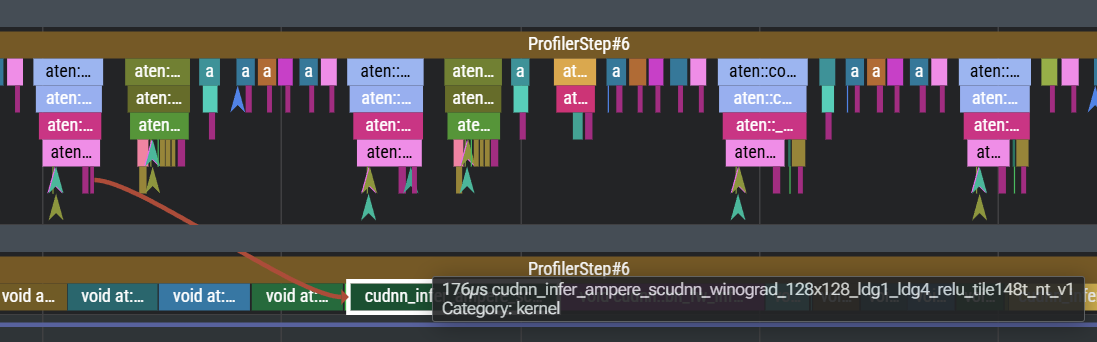

Используется свёрточное ядро cudnn_infer_ampere_scudnn_winograd_128x128_ldg1_ldg4_relu_tile148t_nt_v1

scudnn означает, что тип входных данных - fp32, как и ожидалось

# Квантизация с использованием Triton-ядра на инференсе 

Напишем кастомное ядро, которое будет использовать целочисленное перемножение при вычислении свёрток
Нужно убедиться, что обученная модель загружена заново и содержит веса QAConv2d

In [14]:
import torch
import torch.nn as nn
import triton
import triton.language as tl

@triton.autotune(
    configs=[
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32}, num_stages=5, num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32}, num_stages=5, num_warps=2),
    ],
    key=['M', 'N', 'K'],
)
@triton.jit
def lsq_conv_kernel_g1(
    x_ptr, w_ptr, bias_ptr, out_ptr,
    batch, in_c, in_h, in_w, out_c, out_h, out_w,
    kh, kw, stride_h, stride_w, padding_h, padding_w,
    scale, M, N, K,
    stride_xb, stride_xc, stride_xh, stride_xw,
    stride_w_out, stride_w_in, stride_w_kh, stride_w_kw,
    stride_out_b, stride_out_c, stride_out_h, stride_out_w,
    stride_bias,
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
):
    pid = tl.program_id(0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    pid_m = pid % num_pid_m
    pid_n = pid // num_pid_m

    offs_m = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_n = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

    batch_id = offs_m // (out_h * out_w)
    pix_id = offs_m % (out_h * out_w)
    out_y = pix_id // out_w
    out_x = pix_id % out_w

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.int32)

    for k_base in range(0, K, BLOCK_SIZE_K):
        offs_k = k_base + tl.arange(0, BLOCK_SIZE_K)
        k_ch = offs_k // (kh * kw)
        k_rem = offs_k % (kh * kw)
        k_h = k_rem // kw
        k_w = k_rem % kw

        cy = out_y[:, None] * stride_h + k_h[None, :] - padding_h
        cx = out_x[:, None] * stride_w + k_w[None, :] - padding_w
        
        mask_x = (offs_m[:, None] < M) & (offs_k[None, :] < K) & \
                 (cy >= 0) & (cy < in_h) & (cx >= 0) & (cx < in_w)

        off_x = (batch_id[:, None].to(tl.int64) * stride_xb + k_ch[None, :].to(tl.int64) * stride_xc + 
                 cy.to(tl.int64) * stride_xh + cx.to(tl.int64) * stride_xw)
        off_w = (offs_n[None, :].to(tl.int64) * stride_w_out + k_ch[:, None].to(tl.int64) * stride_w_in + 
                 k_h[:, None].to(tl.int64) * stride_w_kh + k_w[:, None].to(tl.int64) * stride_w_kw)
        
        a = tl.load(x_ptr + off_x, mask=mask_x, other=0).to(tl.int8)
        b = tl.load(w_ptr + off_w, mask=(offs_k[:, None] < K) & (offs_n[None, :] < N), other=0).to(tl.int8)
        accumulator += tl.dot(a, b)

    bias_vals = tl.load(bias_ptr + offs_n * stride_bias, mask=offs_n < N, other=0.0)
    out = accumulator.to(tl.float32) * scale + bias_vals[None, :].to(tl.float32)
    
    off_out = (batch_id[:, None].to(tl.int64) * stride_out_b + offs_n[None, :].to(tl.int64) * stride_out_c + 
               out_y[:, None].to(tl.int64) * stride_out_h + out_x[:, None].to(tl.int64) * stride_out_w)
    tl.store(out_ptr + off_out, out, mask=(offs_m[:, None] < M) & (offs_n[None, :] < N))

In [15]:
class LSQConv2dTriton(nn.Module):
    def __init__(self, lsq_layer):
        super().__init__()
        self.stride = lsq_layer.stride
        self.padding = lsq_layer.padding
        self.static_padding = getattr(lsq_layer, 'static_padding', None)
        
        device = lsq_layer.weight.device

        self.register_buffer('Qn', torch.tensor(lsq_layer.Qn, dtype=torch.float32, device=device))
        self.register_buffer('Qp', torch.tensor(lsq_layer.Qp, dtype=torch.float32, device=device))
        self.register_buffer('x_scale', lsq_layer.x_scale.data.clone().to(device))
        
        with torch.no_grad():
            sw = lsq_layer.weight_scale.data
            sa = lsq_layer.x_scale.data
            self.combined_scale = (sw * sa).item()

            w_int = torch.clamp(torch.round(lsq_layer.weight.data / sw), lsq_layer.Qn, lsq_layer.Qp).to(torch.int8)
            self.register_buffer('weight_int', w_int.to(memory_format=torch.channels_last))

            if lsq_layer.bias is not None:
                self.register_buffer('bias', lsq_layer.bias.data.clone())
            else:
                self.register_buffer('bias', torch.zeros(lsq_layer.out_channels, device=sw.device))
                
        self.out_c, self.in_c, self.kh, self.kw = self.weight_int.shape
        self.K_val = self.in_c * self.kh * self.kw
        self.sh, self.sw = (self.stride, self.stride) if isinstance(self.stride, int) else self.stride
        self.ph, self.pw = (self.padding, self.padding) if isinstance(self.padding, int) else self.padding

    def forward(self, x):
        if not x.is_contiguous(memory_format=torch.channels_last):
            x = x.to(memory_format=torch.channels_last)

        if self.static_padding is not None:
            x = self.static_padding(x)

        x_q = torch.clamp(torch.round(x / self.x_scale), self.Qn, self.Qp).to(torch.int8)
        
        B, C, H, W = x_q.shape
        OH, OW = (H + 2*self.ph - self.kh) // self.sh + 1, (W + 2*self.pw - self.kw) // self.sw + 1
        M, N = B * OH * OW, self.out_c
        
        output = torch.empty((B, self.out_c, OH, OW), device=x.device, 
                             dtype=torch.float32, memory_format=torch.channels_last)

        output = torch.empty((B, self.out_c, OH, OW), device=x.device, 
                             dtype=torch.float32, memory_format=torch.channels_last)

        grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(self.out_c, META['BLOCK_SIZE_N']),)

        lsq_conv_kernel_g1[grid](
            x_q, self.weight_int, self.bias, output,
            B, C, H, W, self.out_c, OH, OW, self.kh, self.kw, self.sh, self.sw, self.ph, self.pw,
            self.combined_scale, M, self.out_c, self.K_val,
            x_q.stride(0), x_q.stride(1), x_q.stride(2), x_q.stride(3),
            self.weight_int.stride(0), self.weight_int.stride(1), self.weight_int.stride(2), self.weight_int.stride(3),
            output.stride(0), output.stride(1), output.stride(2), output.stride(3),
            self.bias.stride(0)
        )
        return output

def convert_qaconv_to_triton(model):
    """
    Заменяет все QAConv2d с groups=1 на Triton-версию.
    Групповые свертки (Depthwise) заменяются на QAConv2dInference.
    """
    def replace_recursive(module):
        for name, child in module.named_children():
            if isinstance(child, QAConv2d):
                if child.groups == 1:
                    setattr(module, name, LSQConv2dTriton(child))
                else:
                    setattr(module, name, QAConv2dInference(child))
            else:
                replace_recursive(child)
    
    replace_recursive(model)
    return model

In [16]:
model.to(device)
model.eval()

model = convert_qaconv_to_triton(model)
model.to(memory_format=torch.channels_last)
count_layers(model)

Слоев для обучения (QAConv2d): 0
Слоев для инференса (QAConv2dInference): 32
Слоев для инференса (LSQConv2dTriton): 166
Обычных слоев (Conv2dStaticSamePadding): 2
Обычных слоев (Conv2d): 1


Counter({'LSQConv2dTriton': 166,
         'BatchNorm2d': 106,
         'ZeroPad2d': 33,
         'SiLU': 33,
         'MBConvBlock': 32,
         'QAConv2dInference': 32,
         'ReLU': 20,
         'Sequential': 20,
         'Sigmoid': 20,
         'AdaptiveAvgPool2d': 11,
         'Conv2dReLU': 10,
         'Attention': 10,
         'SCSEModule': 10,
         'Identity': 8,
         'UnetDecoderBlock': 5,
         'Conv2dStaticSamePadding': 2,
         'ModuleList': 2,
         'Unet': 1,
         'EfficientNetEncoder': 1,
         'Dropout': 1,
         'UnetDecoder': 1,
         'SegmentationHead': 1,
         'Conv2d': 1,
         'Activation': 1})

In [17]:
# выполняем jit-компиляцию
# нужно подождать, код не завис
example_tensor = torch.ones(
    (1, 3, 512, 512),
    dtype=torch.float32,
    device=device,
)
with torch.no_grad():
    model(example_tensor.to(memory_format=torch.channels_last))

In [18]:
print("Тестируем LSQConv2dTriton (int8 Optimized)...")
time_triton = benchmark_model(model)

Тестируем LSQConv2dTriton (int8 Optimized)...
Начинаем замер для тензора (1, 3, 512, 512)...

--- РЕЗУЛЬТАТЫ ---
Среднее время: 42.823 ms
Отклонение (std): 0.780 ms
------------------



In [24]:
# Вычисления замедлились
# снимем трейс и убедимся что вычисления происходят в int8

profile_model(model, input_size=(1, 3, 224, 224), device=device)
prof.export_chrome_trace("/pub/home/tjumentseva/data/traces/qa_int8_model.json")
print(prof.key_averages().table(sort_by='cpu_time_total'))

 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████▌                 | 6/7 [00:00<00:00, 16.86it/s]STAGE:2026-04-25 16:21:00 2504382:2504382 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-04-25 16:21:00 2504382:2504382 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  6.92it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        51.88%      66.796ms        99.86%     128.576ms      64.288ms       0.000us         0.00%      21.970ms      10.985ms             2  
                                       aten::batch_norm         0.27%     345.000us        10.35%      13.323ms      63.443us       0.000us         0.00%       2.890ms      13.762us           210  
         

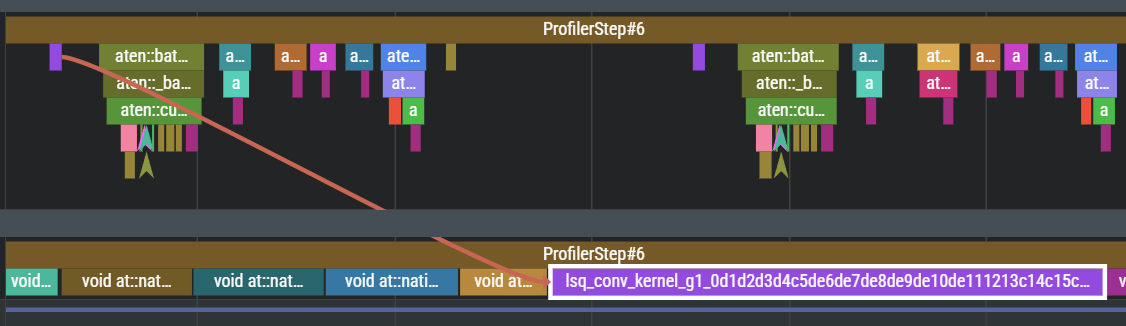

In [32]:
# видно, что входные данные подаются в int8, выходной формат в fp32, как и ожидалось
lsq_conv_kernel_g1.fn.cache

defaultdict(dict,
            {0: {('2-.-3-.-113d7e6971e56e9637f63a45c049f05799753e745-da39a3ee5e6b4b0d3255bfef95601890afd80709-412700a48b69987d320974309c07d7d216eb6461-a5cb8d247c34ba3cc2ce16a5b9a0885940bd4411-1c2eefb50cce523e1229e6f29000d4c4e4c18cc6-c9d967c0bcccd60e29da593ba0e205e4fda729d6-acf32f5db9590afc80ecf0bdfcbb44d0521cbf10-b73229af17874e4b0a75064ebaf7f1b36d576cbb-21283102af478fbb454a8cf1ce7969e0d0d7d0d2-54b201b699b9bf1c7174f64f4935b88a22bf6ed2-3fe25b3016cdedf3e073a57478e0842d49872c36-69d8ca347011915fd215c0ecf54bc7c197d5a6ee-77b54f85ea74b8c7cb818722d81a273c6deb7acf-76ac7b5e0a4ff79fb4366fa55e2322d4f1ab8a15-7ce4b6885e5a4e8135345e992a6db9ba121bf220',
               (torch.int8,
                torch.int8,
                torch.float32,
                torch.float32,
                'i32',
                'i32',
                'i32',
                'i32',
                'i32',
                'i32',
                'i32',
                'i32',
                'i32',
            

# Устранение питоновского оверхэда

In [29]:
def capture_model_graph(model, input_shape=(1, 3, 512, 512)):
    device = "cuda"
    model.to(device)
    model.eval()

    static_input = torch.randn(input_shape, device=device)

    print("Разогрев и компиляция Triton ядер...")
    with torch.no_grad():
        for _ in range(10):
            static_output = model(static_input)

    torch.cuda.synchronize()

    print("Запись CUDA графа...")
    graph = torch.cuda.CUDAGraph()
    
    with torch.cuda.graph(graph):
        static_output = model(static_input)

    def graphed_inference(x):
        static_input.copy_(x)
        graph.replay()
        return static_output

    print("Done")
    return graphed_inference


inference_func = capture_model_graph(model)

Разогрев и компиляция Triton ядер...
Запись CUDA графа...
Done


In [30]:
benchmark_model(inference_func)

Начинаем замер для тензора (1, 3, 512, 512)...

--- РЕЗУЛЬТАТЫ ---
Среднее время: 14.539 ms
Отклонение (std): 0.058 ms
------------------



np.float64(14.53889217376709)